# Semana 9: Laboratorio iteraciones entre limpieza de datos y EDA

**Curso:** Introducción a Business Analytics
**Unidad IV:** Comprensión y Exploración de Datos  
**Tema:** Iteraciones entre limpieza de datos y EDA
**Docente:** Ana Rocío Cárdenas Maita
**Exemplo:** Dataset Titanic
---

## Objetivos de la sesión:

Entender cómo ocurre las iteraciones o ciclos repetitivos de **la limpieza de datos y el EDA** en la práctica real. Estas fases no son etapas separadas son un ciclo. Recuerda esta imagen:

![CRISP-DM](/content/CRISP-DM.jpg)

---

## ¡Comencemos!
En este notebook lo demuestraremos explícitamente con el dataset más famoso del mundo: el **Titanic**.


**Fuente:** librería `seaborn` (incluido por defecto)  
**Tamaño:** 891 pasajeros, 15 columnas  
**Pregunta central:** ¿Qué factores predijeron la supervivencia?

El Titanic dataset es uno de los datasets más usados en ciencia de datos. Registra información de los 891 pasajeros (de 1,309 a bordo) del RMS Titanic, que se hundió en abril de 1912.

**Columnas:**

| Columna | Tipo | Descripción |
|---|---|---|
| `survived` | int | 0 = No sobrevivió, 1 = Sobrevivió *(variable objetivo)* |
| `pclass` | int | Clase del boleto (1 = Alta, 2 = Media, 3 = Baja) |
| `sex` | str | Sexo del pasajero (`male` / `female`) |
| `age` | float | Edad en años (20% de valores nulos) |
| `sibsp` | int | N° de hermanos / cónyuge a bordo |
| `parch` | int | N° de padres / hijos a bordo |
| `fare` | float | Tarifa pagada en libras esterlinas (£) |
| `embarked` | str | Puerto de embarque: `C`=Cherbourg, `Q`=Queenstown, `S`=Southampton |
| `deck` | str | Cubierta del camarote (77% de valores nulos) |
| `class` | str | Clase en texto (`First`, `Second`, `Third`) — duplicado de `pclass` |
| `who` | str | Categoría del pasajero (`man`, `woman`, `child`) — derivada de `sex`+`age` |
| `adult_male` | bool | `True` si es hombre adulto |
| `alone` | bool | `True` si viajaba solo |
| `embark_town` | str | Puerto en texto — duplicado de `embarked` |
| `alive` | str | `yes` / `no` — duplicado de `survived` |


La pregunta es intuitiva: ¿quién sobrevivió y por qué?
Tiene señales claras (clase, sexo) pero también ruido, lo que hace el análisis interesante. Tasa de supervivencia global: ~38%, entonces cada variable es una historia sobre desigualdad social, protocolo de emergencia y azar.

## 0. Importaciones

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display, Markdown

# Estilo visual
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


---
# CICLO 1 — Exploración Inicial
**Objetivo:** Entender qué tenemos antes de tocar nada.

> **Regla de oro:** Nunca limpies lo que no entiendes. Primero observa.

### 1.1 Carga de datos

In [2]:
# Cargamos desde seaborn (sin instalar nada extra)
df_raw = sns.load_dataset('titanic')

print(f'Dataset cargado: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas')
display(df_raw.head(10))

Dataset cargado: 891 filas × 15 columnas


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


### 1.2 Diagnóstico inicial: ¿Qué tipos de datos tenemos?

In [3]:
print('=== TIPOS DE DATOS ===')
print(df_raw.dtypes)
print()
print('=== DIMENSIONES ===')
print(f'Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}')

=== TIPOS DE DATOS ===
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

=== DIMENSIONES ===
Filas: 891 | Columnas: 15


### 1.3 Mapa de valores nulos: El "Rayos X" del dataset

> **Concepto:** Antes de limpiar, necesitamos un mapa completo de los nulos: cuántos son, dónde están, y si tienen patrón.

Columnas con valores nulos:


,Nulos,Porcentaje (%)
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


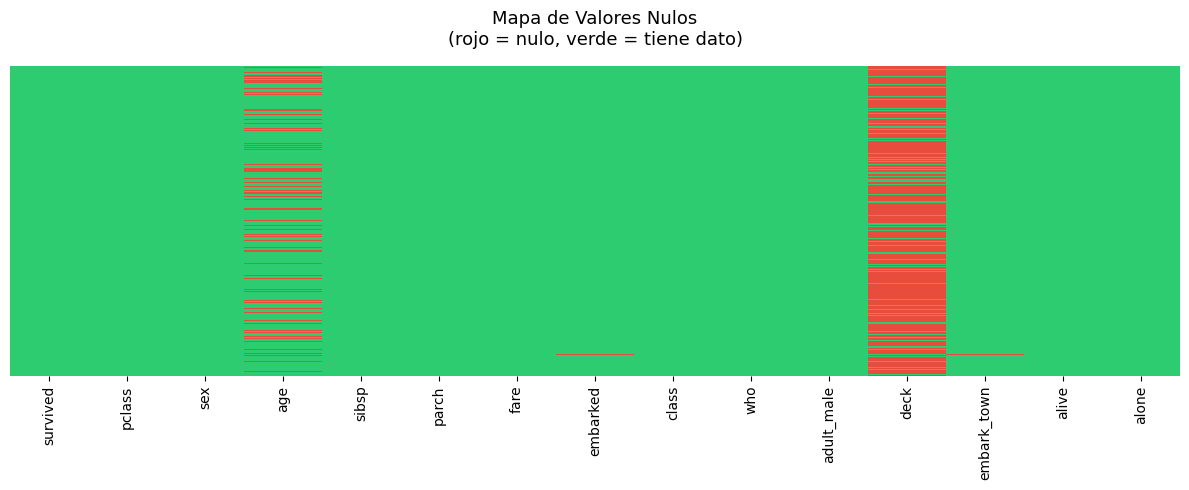

In [4]:
# Tabla de nulos
nulos = pd.DataFrame({
    'Nulos': df_raw.isnull().sum(),
    'Porcentaje (%)': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
}).query('Nulos > 0').sort_values('Porcentaje (%)', ascending=False)

print('Columnas con valores nulos:')
display(nulos)

# Mapa visual de nulos
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False,
            cmap=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title('Mapa de Valores Nulos\n(rojo = nulo, verde = tiene dato)',
             fontsize=13, pad=15)
plt.tight_layout()
plt.show()


In [5]:
print('\n  Hallazgos del mapa de nulos:')
print('  • deck: 77% nulos → decisión: eliminar columna')
print('  • age: 20% nulos → decisión: imputar con mediana por clase')
print('  • embarked/embark_town: 2 nulos → decisión: imputar con moda')


  Hallazgos del mapa de nulos:
  • deck: 77% nulos → decisión: eliminar columna
  • age: 20% nulos → decisión: imputar con mediana por clase
  • embarked/embark_town: 2 nulos → decisión: imputar con moda


**Pregunta**
¿Qué pasa si cambias el umbral del mapa de nulos?
por ejemplo mostrar solo columnas con más del 10% de nulos. ¿Cuáles quedan?

### 1.4 EDA Inicial — Distribuciones antes de limpiar

> **¿Por qué hacer EDA antes de limpiar?** Para entender el contexto y tomar mejores decisiones de limpieza.

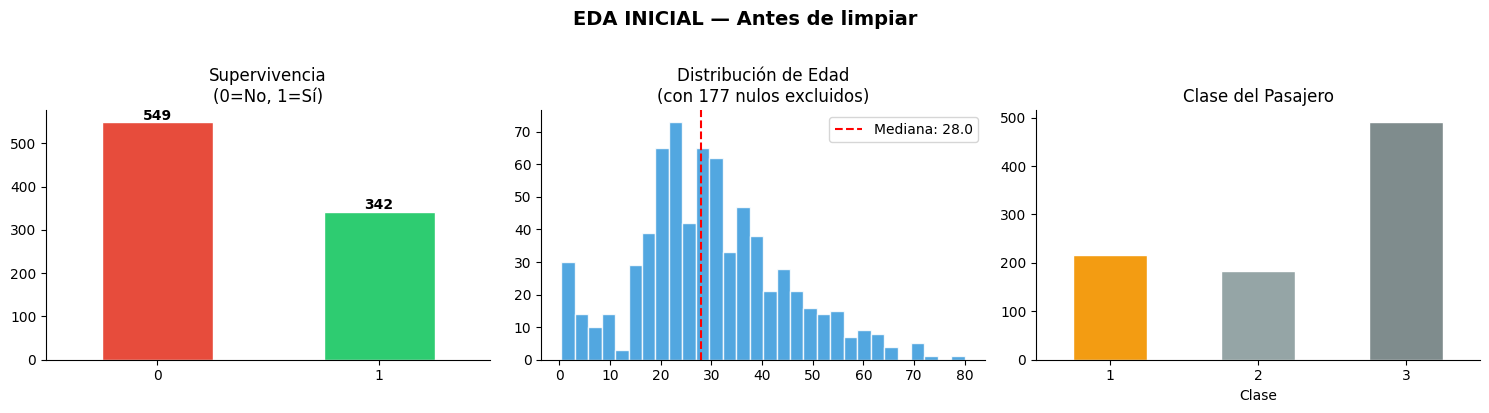

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Variable objetivo
df_raw['survived'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Supervivencia\n(0=No, 1=Sí)', fontsize=12)
axes[0].set_xlabel('')
axes[0].tick_params(rotation=0)
for i, v in enumerate(df_raw['survived'].value_counts()):
    axes[0].text(i, v + 5, f'{v}', ha='center', fontweight='bold')

# Distribución de edad (CON nulos todavía)
axes[1].hist(df_raw['age'].dropna(), bins=30, color='#3498db', edgecolor='white', alpha=0.85)
axes[1].set_title(f'Distribución de Edad\n(con {df_raw["age"].isnull().sum()} nulos excluidos)', fontsize=12)
axes[1].axvline(df_raw['age'].median(), color='red', linestyle='--', label=f'Mediana: {df_raw["age"].median()}')
axes[1].legend()

# Clases
df_raw['pclass'].value_counts().sort_index().plot(
    kind='bar', ax=axes[2], color=['#f39c12', '#95a5a6', '#7f8c8d'], edgecolor='white')
axes[2].set_title('Clase del Pasajero', fontsize=12)
axes[2].set_xlabel('Clase')
axes[2].tick_params(rotation=0)

plt.suptitle('EDA INICIAL — Antes de limpiar', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# CICLO 1 — Limpieza de Datos

Ahora que entendemos el dataset, tomamos decisiones **justificadas** para cada problema.

> **Importante:** Siempre trabajamos sobre una copia, nunca sobre el original.

### 2.1 Crear copia de trabajo

In [7]:
df = df_raw.copy()
print('Copia de trabajo creada. df_raw permanece intacto.')
print(f'   Forma: {df.shape}')

Copia de trabajo creada. df_raw permanece intacto.
   Forma: (891, 15)


### 2.2 Eliminar columnas redundantes o con demasiados nulos

| Columna | Problema | Decisión |
|---|---|---|
| `deck` | 77% nulos | ❌ Eliminar |
| `embark_town` | Duplicado de `embarked` | ❌ Eliminar |
| `alive` | Duplicado de `survived` | ❌ Eliminar |
| `class` | Duplicado categórico de `pclass` | ❌ Eliminar |
| `who` | Derivada de `sex`+`age` | ❌ Eliminar |

In [8]:
cols_eliminar = ['deck', 'embark_town', 'alive', 'class', 'who']

print('Columnas ANTES:', df.columns.tolist())
df.drop(columns=cols_eliminar, inplace=True)
print('Columnas DESPUÉS:', df.columns.tolist())
print(f'\nSe eliminaron {len(cols_eliminar)} columnas redundantes.')

Columnas ANTES: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
Columnas DESPUÉS: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'adult_male', 'alone']

Se eliminaron 5 columnas redundantes.


### 2.3 Imputar edad — Estrategia por grupos

> **¿Por qué por grupos?** Imputar con la mediana global ignora que la 1ra clase tenía pasajeros más viejos que la 3ra. Una mediana por `pclass` es más realista.

In [9]:
# Antes de imputar — Medianas por clase
medianas_edad = df.groupby('pclass')['age'].median()
print('Mediana de edad por clase (para imputar):')
print(medianas_edad)
print(f'\nNulos ANTES: {df["age"].isnull().sum()}')

# Imputación
df['age'] = df.groupby('pclass')['age'].transform(
    lambda x: x.fillna(x.median())
)

print(f'Nulos DESPUÉS: {df["age"].isnull().sum()}')
print('Edad imputada con mediana por clase')

Mediana de edad por clase (para imputar):
pclass
1    37.0
2    29.0
3    24.0
Name: age, dtype: float64

Nulos ANTES: 177
Nulos DESPUÉS: 0
Edad imputada con mediana por clase


### 2.4 Imputar embarked (2 nulos) y fare (1 nulo)

In [10]:
# embarked: 2 nulos → moda
moda_embarked = df['embarked'].mode()[0]
df['embarked'].fillna(moda_embarked, inplace=True)
print(f'embarked: imputado con moda = "{moda_embarked}"')

# fare: revisar si hay nulos
if df['fare'].isnull().sum() > 0:
    df['fare'].fillna(df['fare'].median(), inplace=True)
    print('fare: imputado con mediana')
else:
    print('fare: sin nulos, no requiere imputación')

# Verificación final
nulos_restantes = df.isnull().sum().sum()
print(f'\nTotal de nulos restantes: {nulos_restantes}')

embarked: imputado con moda = "S"
fare: sin nulos, no requiere imputación

Total de nulos restantes: 2


/tmp/ipykernel_7254/2365335716.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['embarked'].fillna(moda_embarked, inplace=True)


### 2.5 Crear variables derivadas (Feature Engineering básico)

> **Insight del negocio:** Los pasajeros que viajaban solos vs. en familia pueden tener tasas de supervivencia diferentes.

In [11]:
# Familia total a bordo
df['family_size'] = df['sibsp'] + df['parch'] + 1  # +1 = la persona misma

# Viajero solo
df['is_alone'] = (df['family_size'] == 1).astype(int)

# Grupos de edad
bins = [0, 12, 18, 35, 60, 100]
labels = ['Niño', 'Adolescente', 'Adulto joven', 'Adulto', 'Mayor']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

print('Variables creadas:')
print('  • family_size: tamaño total del grupo familiar')
print('  • is_alone: 1 si viajaba solo, 0 si no')
print('  • age_group: categoría de edad')
print()
print(df[['sibsp', 'parch', 'family_size', 'is_alone', 'age_group']].head(8))

Variables creadas:
  • family_size: tamaño total del grupo familiar
  • is_alone: 1 si viajaba solo, 0 si no
  • age_group: categoría de edad

   sibsp  parch  family_size  is_alone     age_group
0      1      0            2         0  Adulto joven
1      1      0            2         0        Adulto
2      0      0            1         1  Adulto joven
3      1      0            2         0  Adulto joven
4      0      0            1         1  Adulto joven
5      0      0            1         1  Adulto joven
6      0      0            1         1        Adulto
7      3      1            5         0          Niño


### 2.6 Verificar duplicados y tipos de datos

In [12]:
print(f'Filas duplicadas: {df.duplicated().sum()}')

# Corregir tipos si es necesario
df['survived'] = df['survived'].astype(int)
df['pclass'] = df['pclass'].astype('category')

print()
print('Dataset limpio — Resumen final:')
print(f'  Forma: {df.shape}')
print(f'  Nulos: {df.isnull().sum().sum()}')
print(f'  Columnas: {df.columns.tolist()}')
print()
display(df.describe(include='all').T)

Filas duplicadas: 116

Dataset limpio — Resumen final:
  Forma: (891, 13)
  Nulos: 2
  Columnas: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'adult_male', 'alone', 'family_size', 'is_alone', 'age_group']



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,3.0,3.0,491.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,891.0,NaN,NaN,NaN,29.066409,13.244532,0.42,22.0,26.0,37.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adult_male,891,2,True,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alone,891,2,True,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Pregunta** Cambia la estrategia de imputación de age: en lugar de mediana por pclass, usa la mediana global. ¿Cuánto cambia la distribución resultante? ¿Cuál estrategia es más honesta con los datos?

---
# CICLO 2 — EDA Profundo (con datos limpios)

Ahora sí analizamos patrones con confianza. Los datos están completos y consistentes.

> **Pregunta guía:** ¿Quién sobrevivió y por qué?

### 3.1 Tasa de supervivencia global

In [13]:
tasa = df['survived'].mean() * 100
print(f'   Tasa de supervivencia global: {tasa:.1f}%')
print(f'   Sobrevivieron: {df["survived"].sum()} de {len(df)} pasajeros')

   Tasa de supervivencia global: 38.4%
   Sobrevivieron: 342 de 891 pasajeros


### 3.2 Supervivencia por Clase y Sexo — Las variables más poderosas

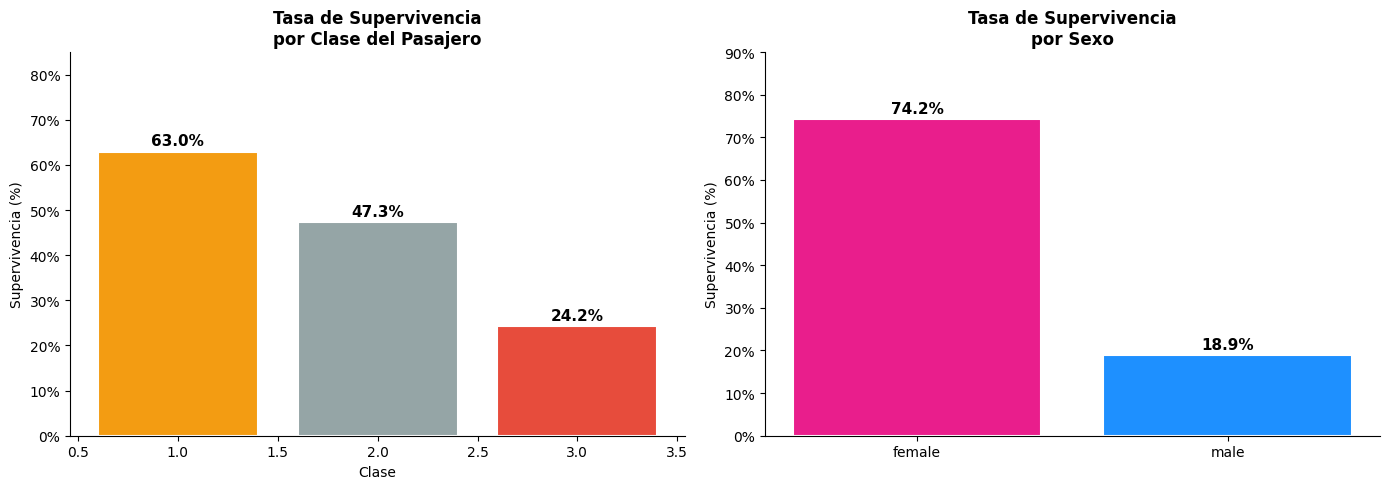

Insights:
   • Las mujeres sobrevivieron a una tasa 3.9x mayor que los hombres
   • Pasajeros de 1ra clase sobrevivieron 2.6x más que los de 3ra


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por clase
surv_clase = df.groupby('pclass')['survived'].mean() * 100
bars1 = axes[0].bar(surv_clase.index, surv_clase.values,
                     color=['#f39c12', '#95a5a6', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Tasa de Supervivencia\npor Clase del Pasajero', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Supervivencia (%)')
axes[0].set_xlabel('Clase')
axes[0].set_ylim(0, 85)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars1, surv_clase.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

# Por sexo
surv_sexo = df.groupby('sex')['survived'].mean() * 100
colores_sexo = {'female': '#e91e8c', 'male': '#1e90ff'}
bars2 = axes[1].bar(surv_sexo.index, surv_sexo.values,
                     color=[colores_sexo[s] for s in surv_sexo.index],
                     edgecolor='white', linewidth=1.5)
axes[1].set_title('Tasa de Supervivencia\npor Sexo', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Supervivencia (%)')
axes[1].set_ylim(0, 90)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars2, surv_sexo.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print('Insights:')
print(f'   • Las mujeres sobrevivieron a una tasa {surv_sexo["female"]/surv_sexo["male"]:.1f}x mayor que los hombres')
print(f'   • Pasajeros de 1ra clase sobrevivieron {surv_clase[1]/surv_clase[3]:.1f}x más que los de 3ra')

### 3.3 El "heat map" de supervivencia — Clase × Sexo

> Esta visualización combina dos variables para revelar patrones que no son visibles por separado.

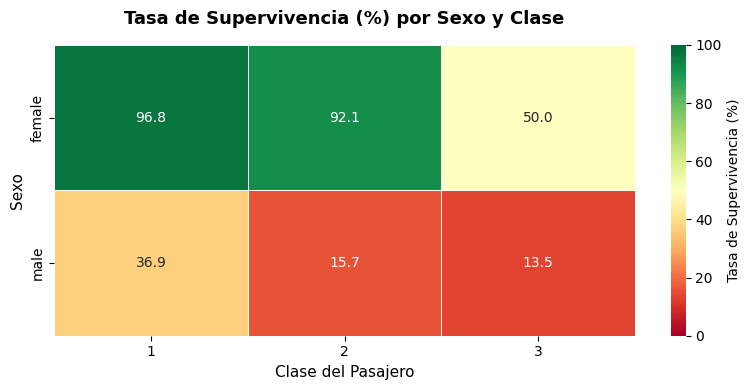

   Insight clave: Una mujer en 1ra clase tenía ~97% de sobrevivir.
   Un hombre en 3ra clase tenía solo ~13% de probabilidad.


In [15]:
pivot = df.pivot_table(values='survived', index='sex', columns='pclass', aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Tasa de Supervivencia (%)'},
            ax=ax, vmin=0, vmax=100)
ax.set_title('Tasa de Supervivencia (%) por Sexo y Clase', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Clase del Pasajero', fontsize=11)
ax.set_ylabel('Sexo', fontsize=11)
plt.tight_layout()
plt.show()

print('   Insight clave: Una mujer en 1ra clase tenía ~97% de sobrevivir.')
print('   Un hombre en 3ra clase tenía solo ~13% de probabilidad.')

### 3.4 Distribución de edad: ¿Sobrevivir dependía de la edad?

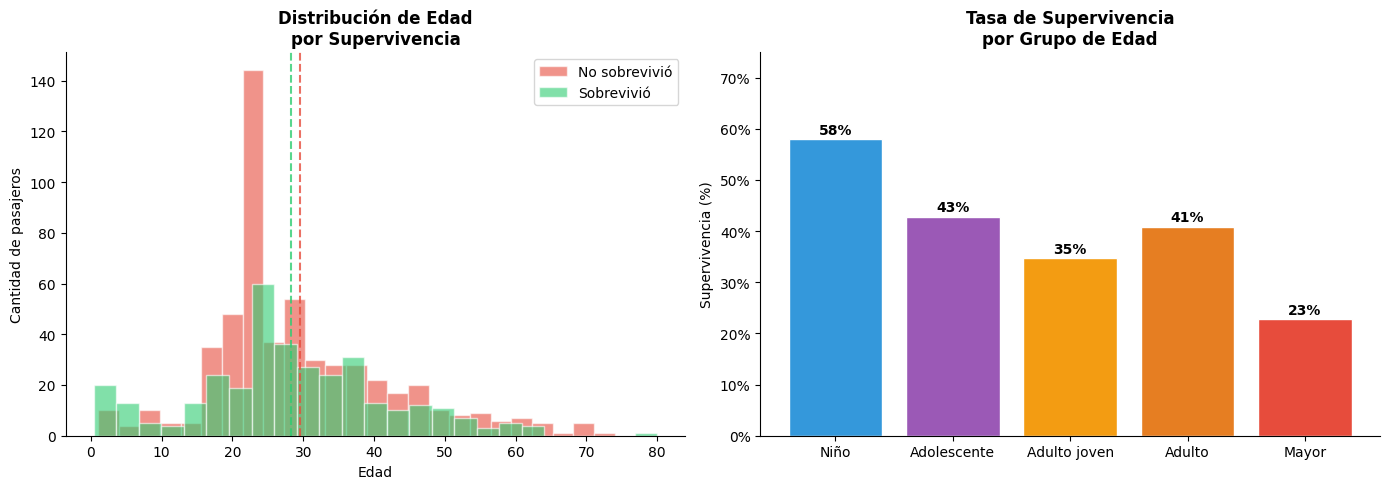

   Los niños (0-12) tuvieron la mayor tasa de supervivencia (~58%)
   Consistente con "mujeres y niños primero"


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución superpuesta
for sobrevivio, color, label in [(0, '#e74c3c', 'No sobrevivió'), (1, '#2ecc71', 'Sobrevivió')]:
    subset = df[df['survived'] == sobrevivio]['age']
    axes[0].hist(subset, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')

axes[0].set_title('Distribución de Edad\npor Supervivencia', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Cantidad de pasajeros')
axes[0].legend()
axes[0].axvline(df[df['survived']==0]['age'].mean(), color='#e74c3c', linestyle='--', alpha=0.8)
axes[0].axvline(df[df['survived']==1]['age'].mean(), color='#2ecc71', linestyle='--', alpha=0.8)

# Por grupo de edad
surv_edad = df.groupby('age_group', observed=True)['survived'].mean() * 100
colores_edad = ['#3498db', '#9b59b6', '#f39c12', '#e67e22', '#e74c3c']
bars = axes[1].bar(surv_edad.index, surv_edad.values, color=colores_edad, edgecolor='white')
axes[1].set_title('Tasa de Supervivencia\npor Grupo de Edad', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Supervivencia (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_ylim(0, 75)
for bar, val in zip(bars, surv_edad.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('   Los niños (0-12) tuvieron la mayor tasa de supervivencia (~58%)')
print('   Consistente con "mujeres y niños primero"')

### 3.5 El efecto del tamaño familiar y viajar solo

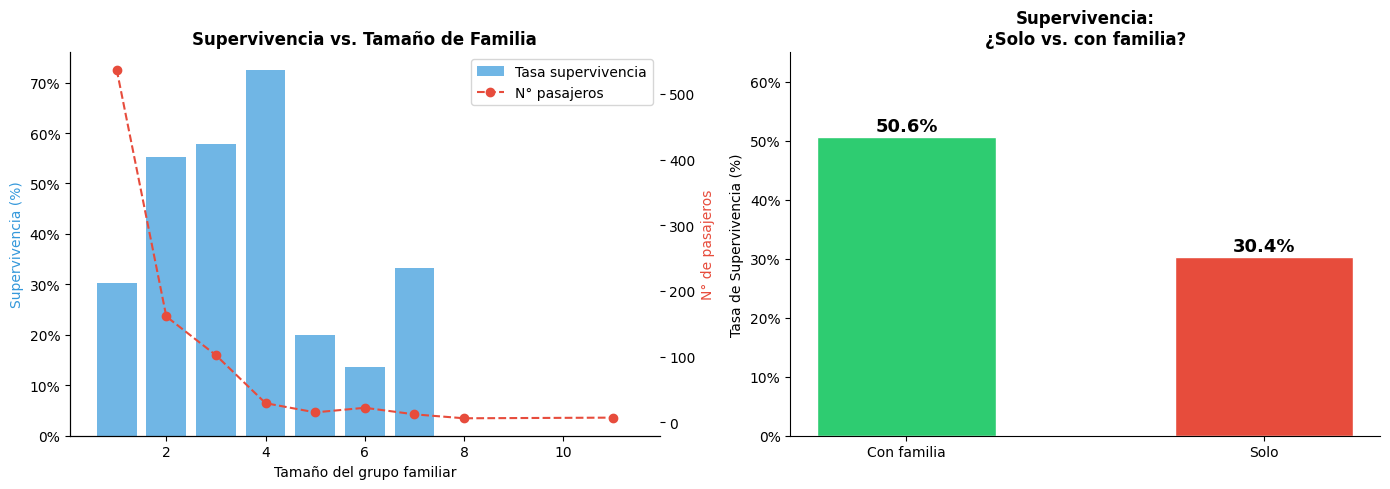

   Pasajeros con familia pequeña (2-4) sobrevivieron más que los solitarios
   Familias muy grandes (7+) tuvieron tasas mínimas de supervivencia


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Supervivencia por tamaño de familia
surv_familia = df.groupby('family_size')['survived'].mean() * 100
count_familia = df.groupby('family_size').size()

ax1 = axes[0]
ax1_twin = ax1.twinx()
ax1.bar(surv_familia.index, surv_familia.values, color='#3498db', alpha=0.7, label='Tasa supervivencia')
ax1_twin.plot(count_familia.index, count_familia.values, 'o--', color='#e74c3c', label='N° pasajeros')
ax1.set_title('Supervivencia vs. Tamaño de Familia', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tamaño del grupo familiar')
ax1.set_ylabel('Supervivencia (%)', color='#3498db')
ax1_twin.set_ylabel('N° de pasajeros', color='#e74c3c')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())

# Líneas de leyenda manuales
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [Patch(facecolor='#3498db', alpha=0.7, label='Tasa supervivencia'),
                   Line2D([0], [0], color='#e74c3c', marker='o', linestyle='--', label='N° pasajeros')]
ax1.legend(handles=legend_elements, loc='upper right')

# Viajero solo vs acompañado
surv_solo = df.groupby('is_alone')['survived'].mean() * 100
bars = axes[1].bar(['Con familia', 'Solo'], surv_solo.values,
                    color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[1].set_title('Supervivencia:\n¿Solo vs. con familia?', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tasa de Supervivencia (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_ylim(0, 65)
for bar, val in zip(bars, surv_solo.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

print('   Pasajeros con familia pequeña (2-4) sobrevivieron más que los solitarios')
print('   Familias muy grandes (7+) tuvieron tasas mínimas de supervivencia')

### 3.6 Tarifa pagada — ¿El dinero compró supervivencia?

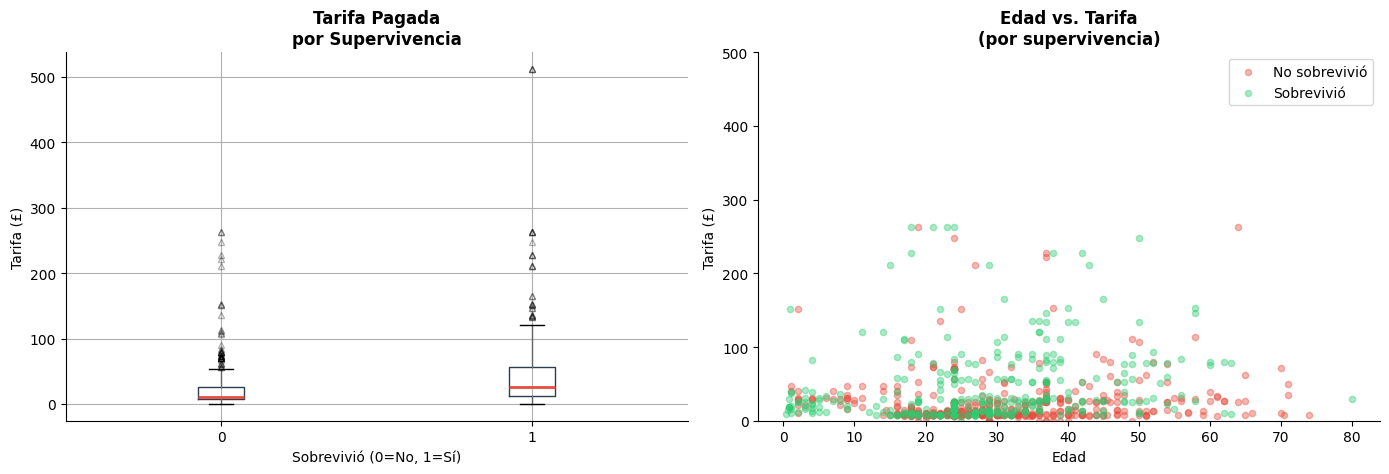

 Mediana de tarifa — Sobrevivió: £26 | No sobrevivió: £10
   Los que sobrevivieron pagaron ~2x más en promedio


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot de tarifa por supervivencia
df.boxplot(column='fare', by='survived', ax=axes[0],
           boxprops=dict(color='#2c3e50'),
           medianprops=dict(color='#e74c3c', linewidth=2),
           flierprops=dict(marker='^', alpha=0.3, markersize=4))
axes[0].set_title('Tarifa Pagada\npor Supervivencia', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sobrevivió (0=No, 1=Sí)')
axes[0].set_ylabel('Tarifa (£)')
plt.suptitle('')  # elimina el título automático de boxplot

# Scatter: edad vs tarifa, coloreado por supervivencia
colores_scatter = {0: '#e74c3c', 1: '#2ecc71'}
for sobrevivio in [0, 1]:
    subset = df[df['survived'] == sobrevivio]
    axes[1].scatter(subset['age'], subset['fare'],
                    c=colores_scatter[sobrevivio],
                    alpha=0.4, s=20,
                    label='Sobrevivió' if sobrevivio else 'No sobrevivió')

axes[1].set_title('Edad vs. Tarifa\n(por supervivencia)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('Tarifa (£)')
axes[1].legend()
axes[1].set_ylim(0, 500)  # excluimos outliers extremos para mejor visualización

plt.tight_layout()
plt.show()

fare_surv = df.groupby('survived')['fare'].median()
print(f' Mediana de tarifa — Sobrevivió: £{fare_surv[1]:.0f} | No sobrevivió: £{fare_surv[0]:.0f}')
print('   Los que sobrevivieron pagaron ~2x más en promedio')

### 3.7 Correlaciones — Visión global de relaciones

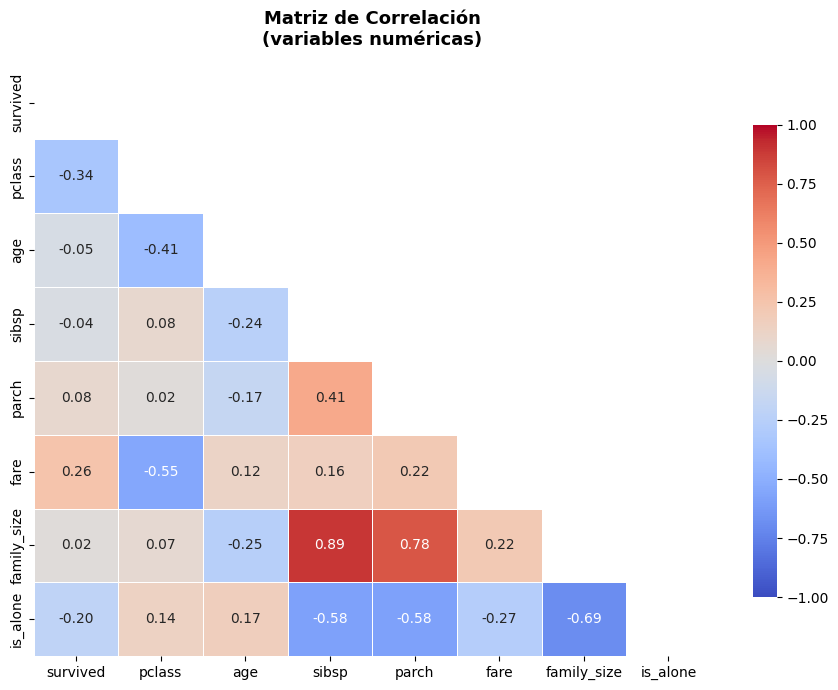

 Correlación con "survived" (de mayor a menor valor absoluto):
  pclass          -0.338  ██████
  fare            +0.257  █████
  is_alone        -0.203  ████
  parch           +0.082  █
  age             -0.047  
  sibsp           -0.035  
  family_size     +0.017  


In [19]:
# Solo columnas numéricas
df_num = df[['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone']].copy()
df_num['pclass'] = df_num['pclass'].astype(int)

corr = df_num.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Solo triángulo inferior
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, linecolor='white',
            vmin=-1, vmax=1, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlación\n(variables numéricas)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Correlaciones con survived ordenadas
corr_survived = corr['survived'].drop('survived').sort_values(key=abs, ascending=False)
print(' Correlación con "survived" (de mayor a menor valor absoluto):')
for col, val in corr_survived.items():
    barra = '█' * int(abs(val) * 20)
    signo = '+' if val > 0 else '-'
    print(f'  {col:<15} {signo}{abs(val):.3f}  {barra}')

**Pregunta** En el heatmap de Clase × Sexo, agrega una tercera dimensión: filtra solo pasajeros mayores de 18. ¿Cambia el patrón para los hombres?

---
# CICLO 2 — Nueva Limpieza (descubierta en EDA)

> **¿Ves el ciclo?** El EDA reveló nuevos problemas que no eran visibles al principio.

**Problema descubierto:** La variable `fare` tiene outliers extremos que distorsionan análisis.

### 4.1 Detectar y tratar outliers en fare

 Estadísticas de fare:
   Q1: £7.91 | Q3: £31.00 | IQR: £23.09
   Límite superior: £65.63
   Outliers detectados: 116 pasajeros (13.0%)
   Tarifa máxima: £512.33

 Estrategia: Winsorización (cap en £65.63)
   Se creó columna "fare_capped" para análisis comparativos


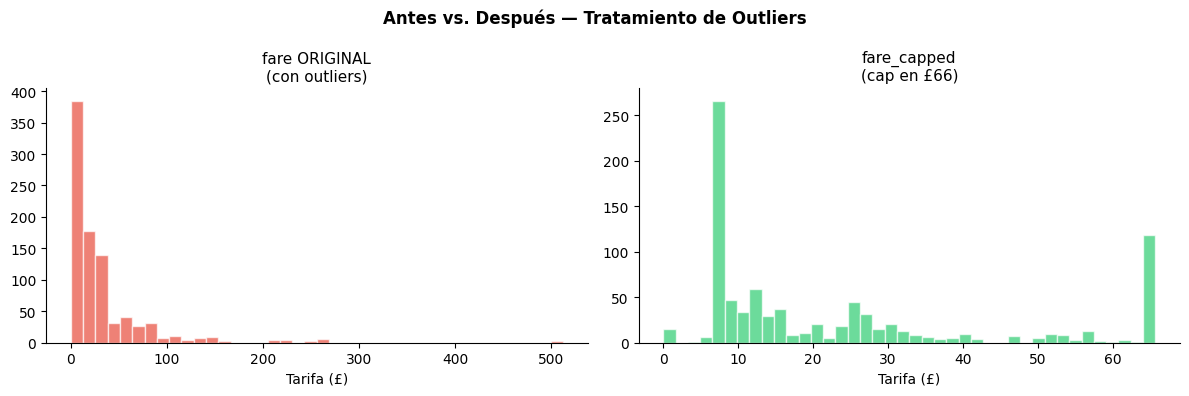

In [20]:
# Método IQR
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers_fare = df[df['fare'] > limite_superior]

print(f' Estadísticas de fare:')
print(f'   Q1: £{Q1:.2f} | Q3: £{Q3:.2f} | IQR: £{IQR:.2f}')
print(f'   Límite superior: £{limite_superior:.2f}')
print(f'   Outliers detectados: {len(outliers_fare)} pasajeros ({len(outliers_fare)/len(df)*100:.1f}%)')
print(f'   Tarifa máxima: £{df["fare"].max():.2f}')

# Decisión: Winsorizamos (cap) en lugar de eliminar
# ¿Por qué? Eliminar filas significa perder info de supervivencia real
df['fare_capped'] = df['fare'].clip(upper=limite_superior)

print(f'\n Estrategia: Winsorización (cap en £{limite_superior:.2f})')
print('   Se creó columna "fare_capped" para análisis comparativos')

# Comparación visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['fare'], bins=40, color='#e74c3c', alpha=0.7, edgecolor='white')
axes[0].set_title('fare ORIGINAL\n(con outliers)', fontsize=11)
axes[0].set_xlabel('Tarifa (£)')

axes[1].hist(df['fare_capped'], bins=40, color='#2ecc71', alpha=0.7, edgecolor='white')
axes[1].set_title(f'fare_capped\n(cap en £{limite_superior:.0f})', fontsize=11)
axes[1].set_xlabel('Tarifa (£)')

plt.suptitle('Antes vs. Después — Tratamiento de Outliers', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# CICLO 3 — EDA Final con datos completamente limpios

### 5.1 Dashboard final de supervivencia

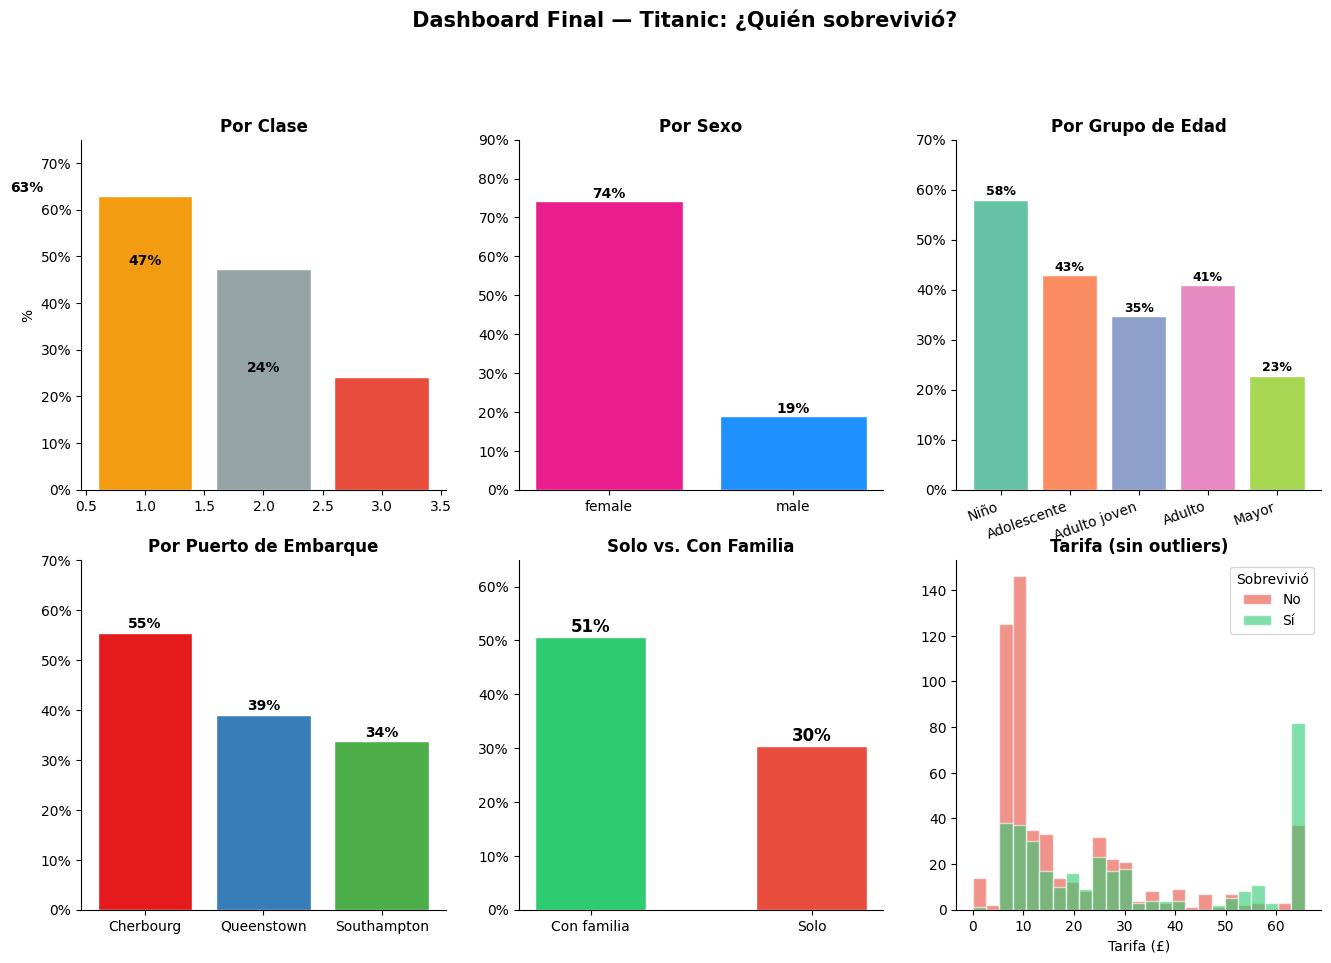

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(' Dashboard Final — Titanic: ¿Quién sobrevivió?',
             fontsize=15, fontweight='bold', y=1.01)

# 1. Clase
surv_clase = df.groupby('pclass', observed=True)['survived'].mean() * 100
axes[0,0].bar(surv_clase.index, surv_clase.values, color=['#f39c12','#95a5a6','#e74c3c'], edgecolor='white')
axes[0,0].set_title('Por Clase', fontweight='bold')
axes[0,0].set_ylabel('%')
axes[0,0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0,0].set_ylim(0, 75)
for i, (idx, val) in enumerate(surv_clase.items()):
    axes[0,0].text(i, val+1, f'{val:.0f}%', ha='center', fontweight='bold')

# 2. Sexo
surv_sexo = df.groupby('sex')['survived'].mean() * 100
axes[0,1].bar(surv_sexo.index, surv_sexo.values, color=['#e91e8c','#1e90ff'], edgecolor='white')
axes[0,1].set_title('Por Sexo', fontweight='bold')
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0,1].set_ylim(0, 90)
for i, (idx, val) in enumerate(surv_sexo.items()):
    axes[0,1].text(i, val+1, f'{val:.0f}%', ha='center', fontweight='bold')

# 3. Grupo de edad
surv_edad = df.groupby('age_group', observed=True)['survived'].mean() * 100
axes[0,2].bar(range(len(surv_edad)), surv_edad.values,
              color=sns.color_palette('Set2', len(surv_edad)), edgecolor='white')
axes[0,2].set_xticks(range(len(surv_edad)))
axes[0,2].set_xticklabels(surv_edad.index, rotation=20, ha='right')
axes[0,2].set_title('Por Grupo de Edad', fontweight='bold')
axes[0,2].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0,2].set_ylim(0, 70)
for i, val in enumerate(surv_edad.values):
    axes[0,2].text(i, val+1, f'{val:.0f}%', ha='center', fontweight='bold', fontsize=9)

# 4. Puerto de embarque
surv_embarque = df.groupby('embarked')['survived'].mean() * 100
nombres_puertos = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
labels_puertos = [nombres_puertos.get(p, p) for p in surv_embarque.index]
axes[1,0].bar(labels_puertos, surv_embarque.values, color=sns.color_palette('Set1',3), edgecolor='white')
axes[1,0].set_title('Por Puerto de Embarque', fontweight='bold')
axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1,0].set_ylim(0, 70)
for i, val in enumerate(surv_embarque.values):
    axes[1,0].text(i, val+1, f'{val:.0f}%', ha='center', fontweight='bold')

# 5. Viajero solo vs acompañado
surv_solo = df.groupby('is_alone')['survived'].mean() * 100
axes[1,1].bar(['Con familia', 'Solo'], surv_solo.values, color=['#2ecc71','#e74c3c'], edgecolor='white', width=0.5)
axes[1,1].set_title('Solo vs. Con Familia', fontweight='bold')
axes[1,1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1,1].set_ylim(0, 65)
for i, val in enumerate(surv_solo.values):
    axes[1,1].text(i, val+1, f'{val:.0f}%', ha='center', fontweight='bold', fontsize=12)

# 6. Tarifa (fare_capped) vs supervivencia
for sobrevivio, color, label in [(0,'#e74c3c','No'), (1,'#2ecc71','Sí')]:
    axes[1,2].hist(df[df['survived']==sobrevivio]['fare_capped'],
                   bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1,2].set_title('Tarifa (sin outliers)', fontweight='bold')
axes[1,2].set_xlabel('Tarifa (£)')
axes[1,2].legend(title='Sobrevivió')

# plt.tight_layout()
#     plt.show()
# print(' Dashboard guardado como titanic_dashboard.png')

In [22]:
df.to_csv('titanic_limpio.csv', index=False)

---
#  RESUMEN DEL CICLO DE TRABAJO

```
CARGA
  │
  ▼
EDA INICIAL ──────────────────────────────────────────────
  │  • Mapa de nulos: deck(77%), age(20%), embarked(2 filas)
  │  • Tipos de datos: mixtos, algunos mal asignados          
  │  • Distribuciones: edad sesgada, clase desbalanceada      
  ▼
LIMPIEZA 1 ────────────────────────────────────────────────
  │  • Eliminar: deck, embark_town, alive, class, who        
  │  • Imputar age: mediana por pclass                        
  │  • Imputar embarked: moda                                 
  │  • Feature Engineering: family_size, is_alone, age_group  
  ▼
EDA PROFUNDO ──────────────────────────────────────────────
  │  • Clase 1 = 63%, Clase 3 = 24% supervivencia            
  │  • Mujeres 74%, Hombres 19%                               
  │  • Niños con mayor supervivencia relativa                  
  │  ***  NUEVO PROBLEMA: fare tiene outliers extremos         
  ▼
LIMPIEZA 2 ────────────────────────────────────────────────
  │  • Winsorización de fare (IQR method)                     
  │  • Nueva columna: fare_capped                             
  ▼
EDA FINAL ─────────────────────────────────────────────────
     • Dashboard completo
     • Matriz de correlaciones
     • Conclusiones analíticas
```

## Conclusiones principales:

| Factor | Impacto en supervivencia |
|--------|------------------------|
| **Sexo** | Mayor factor individual. Mujeres 3.8x más |
| **Clase** | 1ra clase 2.6x más que 3ra |
| **Edad** | Niños priorizados (protocolo) |
| **Tarifa** | Correlacionada con clase (proxy) |
| **Familia** | Grupos medianos (2-4) con ventaja |

> **Siguiente paso:** Con estos datos limpios y el EDA completado, el dataset está listo para modelado predictivo con `sklearn`.

In [23]:
# Estado final del dataset
print('=' * 50)
print('DATASET FINAL — LISTO PARA MODELADO')
print('=' * 50)
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
print(f'Nulos totales: {df.isnull().sum().sum()}')
print(f'Duplicados: {df.duplicated().sum()}')
print()
print(df.dtypes)
print()
print('El dataset está limpio y listo para la siguiente fase.')

# Guardar CSV limpio
print('Guardado como titanic_limpio.csv')

DATASET FINAL — LISTO PARA MODELADO
Filas: 891 | Columnas: 14
Nulos totales: 2
Duplicados: 116

survived          int64
pclass         category
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
adult_male         bool
alone              bool
family_size       int64
is_alone          int64
age_group      category
fare_capped     float64
dtype: object

El dataset está limpio y listo para la siguiente fase.
Guardado como titanic_limpio.csv
